<a href="https://colab.research.google.com/github/Lariiuki/ASGI/blob/main/Imagem_analise2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [92]:
import pandas as pd

In [93]:
df = pd.read_csv('/content/Analise2 - Cod_CCot_Cot - Custo.csv')

In [94]:
df.head()

,Modelo,duration_minimo,duration_maximo,duration_medio,duration_total,custo_minimo,custo_maximo,custo_media,custo_diff media,custo_total,porc_total
0,gpt-5/CoT,"19,18","59,68","44,01440","880,28","0,017556","0,038811","0,028681",0,"0,573625",0
1,gpt-5/CoD1,"20,26","58,67","40,37000","807,40","0,017151","0,034556","0,027429","-0,001252","0,54858","-4,37"
2,gpt-5/CoD2,"17,51","57,90","41,47800","829,56","0,015899","0,036249","0,027456","-0,001225","0,549115","-4,27"
3,gpt-5/CoD3,"17,47","57,73","41,18700","823,74","0,015875","0,037004","0,027417","-0,001264","0,548345","-4,41"
4,gpt-5/CCoT,"13,89","45,74","27,08350","541,67","0,017621","0,044015","0,028921","0,00024","0,578420","0,84"


In [95]:
colunas_float = ["duration_minimo", "duration_maximo", "duration_medio",
                 "custo_minimo", "custo_maximo", "custo_media"]

for col in colunas_float:
    df[col] = df[col].str.replace(",", ".").astype(float)

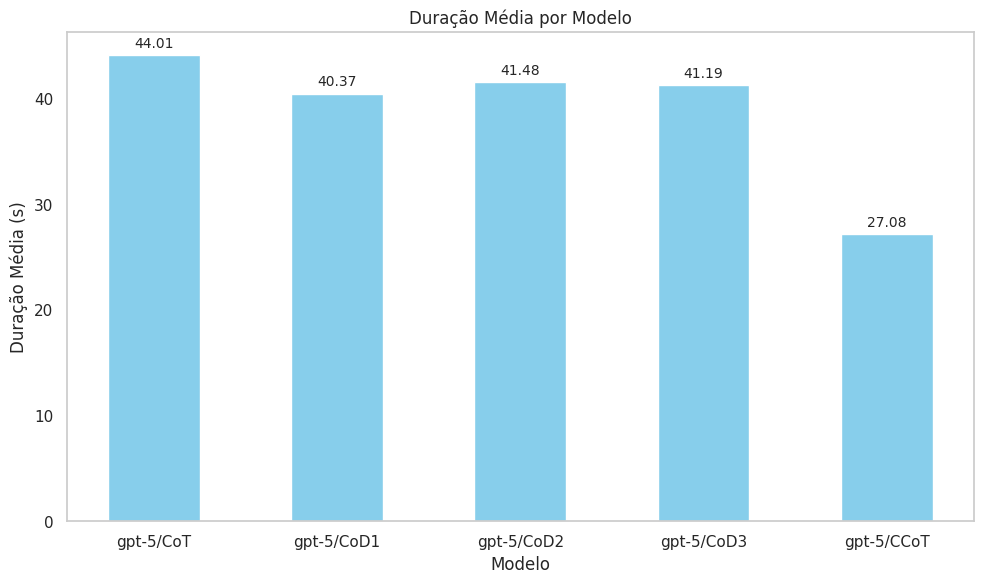

In [96]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

# Gráfico de barras
bars = plt.bar(df["Modelo"], df["duration_medio"], color='skyblue', width=0.5)

# Adicionar valores no topo de cada barra
for bar, valor in zip(bars, df["duration_medio"]):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.5, f"{valor:.2f}",
             ha='center', va='bottom', fontsize=10)

# Labels e título
plt.ylabel('Duração Média (s)')
plt.xlabel('Modelo')
plt.title('Duração Média por Modelo')

# Visual limpo
plt.grid(False)
plt.tight_layout()
plt.show()

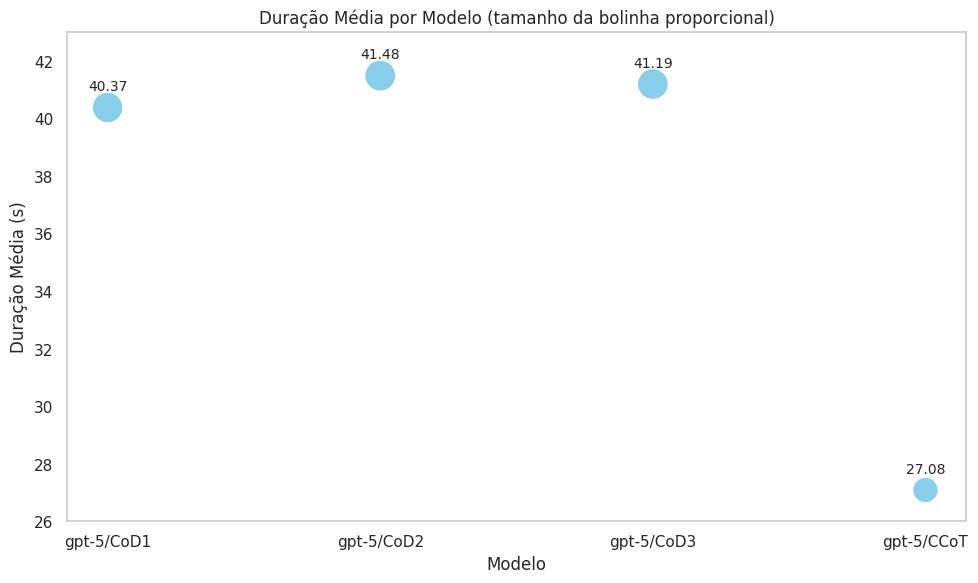

In [146]:
# Filtrar para remover o modelo CoT
df_filtered = df[df["Modelo"] != "gpt-5/CoT"].reset_index(drop=True)

x = np.arange(len(df_filtered))
values = df_filtered["duration_medio"]

plt.figure(figsize=(10,6))

# Tamanho das bolinhas proporcional à duração média
sizes = [val * 10 for val in values]  # ajuste o multiplicador se quiser bolinhas maiores/menores

# Scatter plot (bolinhas)
plt.scatter(x, values, color='skyblue', s=sizes)

# Adicionar valores acima das bolinhas
for xi, val in zip(x, values):
    plt.text(xi, val + 0.5, f"{val:.2f}", ha='center', va='bottom', fontsize=10)

# Rótulos do eixo X
plt.xticks(x, df_filtered["Modelo"], rotation=0, ha='center')

# Limites do eixo Y
plt.ylim(26, 43)

# Labels e título
plt.ylabel('Duração Média (s)')
plt.xlabel('Modelo')
plt.title('Duração Média por Modelo (tamanho da bolinha proporcional)')

# Visual limpo
plt.grid(False)
plt.tight_layout()
plt.show()

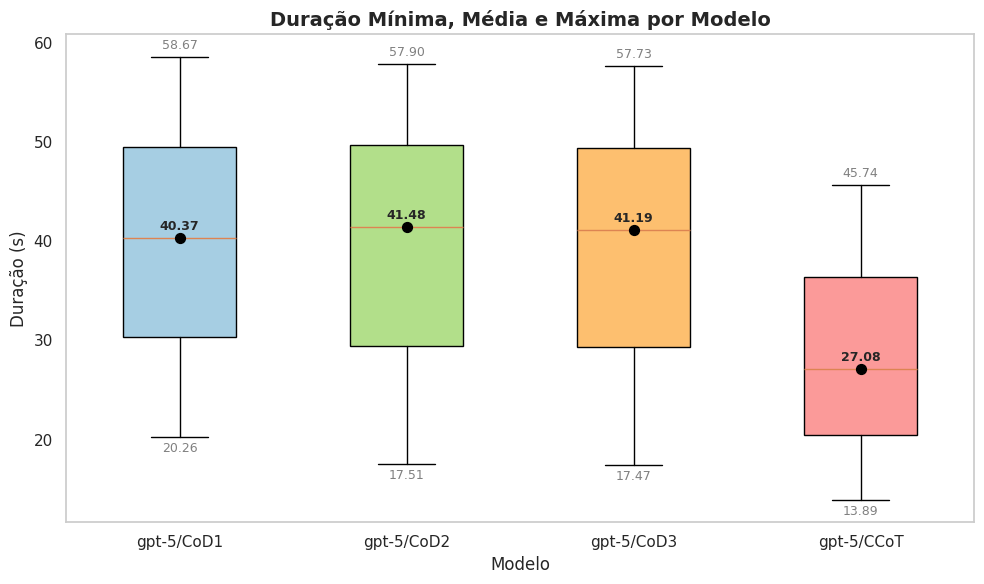

In [149]:
# Filtrar para remover o modelo CoT
df_filtered = df[df["Modelo"] != "gpt-5/CoT"].reset_index(drop=True)

# Preparar dados: cada lista contém min, media, max
data = []
for i, row in df_filtered.iterrows():
    data.append([row["duration_minimo"], row["duration_medio"], row["duration_maximo"]])

plt.figure(figsize=(10,6))

# Boxplot (customizado)
box = plt.boxplot(data, positions=np.arange(len(df_filtered)), widths=0.5, patch_artist=True,
                  showmeans=False, showfliers=False, whis=[0, 100])  # whis para min/max

# Cores suaves para cada box
colors = ['#A6CEE3', '#B2DF8A', '#FDBF6F', '#FB9A99']
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

# Marcar a média como bolinha e adicionar valores
for i, row in enumerate(df_filtered.itertuples()):
    # Média
    plt.scatter(i, row.duration_medio, color='black', s=50, zorder=3)
    plt.text(i, row.duration_medio + 0.5, f"{row.duration_medio:.2f}", ha='center', va='bottom', fontsize=9, fontweight='bold')

    # Mínimo
    plt.text(i, row.duration_minimo - 0.5, f"{row.duration_minimo:.2f}", ha='center', va='top', fontsize=9, color='gray')

    # Máximo
    plt.text(i, row.duration_maximo + 0.5, f"{row.duration_maximo:.2f}", ha='center', va='bottom', fontsize=9, color='gray')

# Rótulos do eixo X
plt.xticks(np.arange(len(df_filtered)), df_filtered["Modelo"], rotation=0, ha='center')

# Labels e título
plt.ylabel('Duração (s)')
plt.xlabel('Modelo')
plt.title('Duração Mínima, Média e Máxima por Modelo', fontsize=14, fontweight='bold')

plt.grid(False)
plt.tight_layout()
plt.show()

In [97]:
df["custo_diff media"] = df["custo_diff media"].str.replace(',', '.').astype(float)

In [98]:
# Mostrar colunas importantes
display(df[["Modelo", "custo_media", "custo_diff media"]])

,Modelo,custo_media,custo_diff media
0,gpt-5/CoT,0.028681,0.000000
1,gpt-5/CoD1,0.027429,-0.001252
2,gpt-5/CoD2,0.027456,-0.001225
3,gpt-5/CoD3,0.027417,-0.001264
4,gpt-5/CCoT,0.028921,0.000240


,Modelo,custo_media,custo_diff media
0,gpt-5/CoD1,0.027429,-0.001252
1,gpt-5/CoD2,0.027456,-0.001225
2,gpt-5/CoD3,0.027417,-0.001264
3,gpt-5/CCoT,0.028921,0.000240


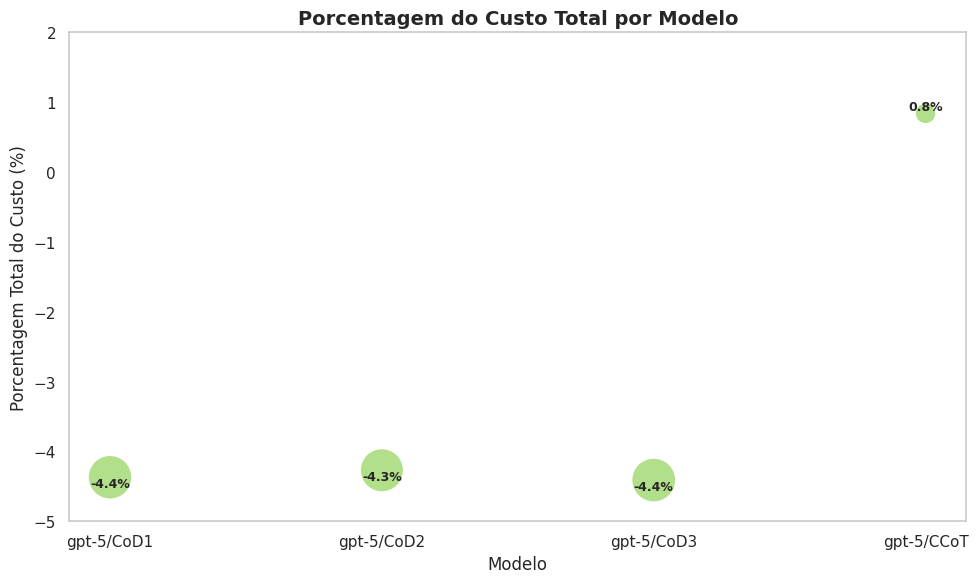

In [158]:
import matplotlib.pyplot as plt
import numpy as np

# Filtrar para remover o modelo CoT
df_filtered = df[df["Modelo"] != "gpt-5/CoT"].reset_index(drop=True)

# Agora exibir apenas as colunas desejadas
display(df_filtered[["Modelo", "custo_media", "custo_diff media"]])

# Filtrar para remover o modelo CoT
df_filtered = df[df["Modelo"] != "gpt-5/CoT"].reset_index(drop=True)

x = np.arange(len(df_filtered))
values = df_filtered["porc_total"]

plt.figure(figsize=(10,6))

# Definir tamanho da bolinha proporcional ao valor absoluto
# Multiplicador ajusta a escala visual
sizes = [abs(val)*200 for val in values]

# Scatter plot com tamanho variável
plt.scatter(x, values, color='#B2DF8A', s=sizes)

# Adicionar valores acima/abaixo das bolinhas
for xi, val in zip(x, values):
    offset = 0.00004 if val >= 0 else -0.00004
    va = 'bottom' if val >= 0 else 'top'
    plt.text(xi, val + offset, f"{val:.1f}%", ha='center', va=va, fontsize=9, fontweight='bold')

# Rótulos do eixo X
plt.xticks(x, df_filtered["Modelo"], rotation=0, ha='center')

plt.ylim(-5, 2)

# Labels e título
plt.ylabel('Porcentagem Total do Custo (%)', fontsize=12)
plt.xlabel('Modelo', fontsize=12)
plt.title('Porcentagem do Custo Total por Modelo', fontsize=14, fontweight='bold')

plt.grid(False)
plt.tight_layout()
plt.show()